# Fase 1 — Exploración y Diagnóstico del Dataset
**Dataset:** Olist Brazilian E-Commerce  
**Objetivo:** Identificar problemas de calidad de datos antes de cualquier transformación.  
**Autor:** Data Engineer Intern  

---

## 0. Setup e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100


## 1. Carga de Datos

In [6]:
customers    = pd.read_csv('../data/raw/olist_customers_dataset.csv')
orders       = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items  = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
products     = pd.read_csv('../data/raw/olist_products_dataset.csv')
payments     = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews      = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
sellers      = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
geolocation  = pd.read_csv('../data/raw/olist_geolocation_dataset.csv')

tables = {
    'customers':   customers,
    'orders':      orders,
    'order_items': order_items,
    'products':    products,
    'payments':    payments,
    'reviews':     reviews,
    'sellers':     sellers,
    'geolocation': geolocation,
}

for name, df in tables.items():
    print(f'   {name:<15} → {df.shape[0]:>7,} filas  ×  {df.shape[1]:>2} columnas')

   customers       →  99,441 filas  ×   5 columnas
   orders          →  99,441 filas  ×   8 columnas
   order_items     → 112,650 filas  ×   7 columnas
   products        →  32,951 filas  ×   9 columnas
   payments        → 103,886 filas  ×   5 columnas
   reviews         →  99,224 filas  ×   7 columnas
   sellers         →   3,095 filas  ×   4 columnas
   geolocation     → 1,000,163 filas  ×   5 columnas


## 2. Resumen General de Calidad
Vista rápida de nulos, duplicados y tipos de dato por tabla.

In [7]:
def quality_summary(name, df):
    """Retorna un DataFrame con métricas de calidad por columna."""
    total = len(df)
    summary = pd.DataFrame({
        'dtype':        df.dtypes,
        'nulls':        df.isnull().sum(),
        'null_%':       (df.isnull().sum() / total * 100).round(2),
        'unique':       df.nunique(),
        'unique_%':     (df.nunique() / total * 100).round(2),
        'sample_value': df.iloc[0]
    })
    summary.index.name = 'column'
    duplicates = df.duplicated().sum()
    display(Markdown(f'###  `{name}` — {total:,} filas | {duplicates:,} duplicados ({duplicates/total*100:.2f}%)'))
    display(summary)
    return summary

summaries = {}
for name, df in tables.items():
    summaries[name] = quality_summary(name, df)
    print()

###  `customers` — 99,441 filas | 0 duplicados (0.00%)

,dtype,nulls,null_%,unique,unique_%,sample_value
column,,,,,,
customer_id,str,0,0.0,99441,100.00,06b8999e2fba1a1fbc88172c00ba8bc7
customer_unique_id,str,0,0.0,96096,96.64,861eff4711a542e4b93843c6dd7febb0
customer_zip_code_prefix,int64,0,0.0,14994,15.08,14409
customer_city,str,0,0.0,4119,4.14,franca
customer_state,str,0,0.0,27,0.03,SP


###  `orders` — 99,441 filas | 0 duplicados (0.00%)

,dtype,nulls,null_%,unique,unique_%,sample_value
column,,,,,,
order_id,str,0,0.00,99441,100.00,e481f51cbdc54678b7cc49136f2d6af7
customer_id,str,0,0.00,99441,100.00,9ef432eb6251297304e76186b10a928d
order_status,str,0,0.00,8,0.01,delivered
order_purchase_timestamp,str,0,0.00,98875,99.43,2017-10-02 10:56:33
order_approved_at,str,160,0.16,90733,91.24,2017-10-02 11:07:15
order_delivered_carrier_date,str,1783,1.79,81018,81.47,2017-10-04 19:55:00
order_delivered_customer_date,str,2965,2.98,95664,96.20,2017-10-10 21:25:13
order_estimated_delivery_date,str,0,0.00,459,0.46,2017-10-18 00:00:00


###  `order_items` — 112,650 filas | 0 duplicados (0.00%)

...

,dtype,nulls,null_%,unique,unique_%,sample_value
column,,,,,,
review_id,str,0,0.00,98410,99.18,7bc2406110b926393aa56f80a40eba40
order_id,str,0,0.00,98673,99.44,73fc7af87114b39712e6da79b0a377eb
review_score,int64,0,0.00,5,0.01,4
review_comment_title,str,87656,88.34,4527,4.56,NaN
review_comment_message,str,58247,58.70,36159,36.44,NaN
review_creation_date,str,0,0.00,636,0.64,2018-01-18 00:00:00
review_answer_timestamp,str,0,0.00,98248,99.02,2018-01-18 21:46:59


###  `sellers` — 3,095 filas | 0 duplicados (0.00%)

,dtype,nulls,null_%,unique,unique_%,sample_value
column,,,,,,
seller_id,str,0,0.0,3095,100.00,3442f8959a84dea7ee197c632cb2df15
seller_zip_code_prefix,int64,0,0.0,2246,72.57,13023
seller_city,str,0,0.0,611,19.74,campinas
seller_state,str,0,0.0,23,0.74,SP


###  `geolocation` — 1,000,163 filas | 261,831 duplicados (26.18%)

,dtype,nulls,null_%,unique,unique_%,sample_value
column,,,,,,
geolocation_zip_code_prefix,int64,0,0.0,19015,1.90,1037
geolocation_lat,float64,0,0.0,717360,71.72,-23.545621
geolocation_lng,float64,0,0.0,717613,71.75,-46.639292
geolocation_city,str,0,0.0,8011,0.80,sao paulo
geolocation_state,str,0,0.0,27,0.00,SP


## 3. Diagnóstico por Tabla

---
### 3.1 `customers`

Duplicados en customer_id (PK): 0
customer_id únicos:        99,441
customer_unique_id únicos: 96,096
→ Un mismo comprador puede tener múltiples customer_id (uno por pedido)


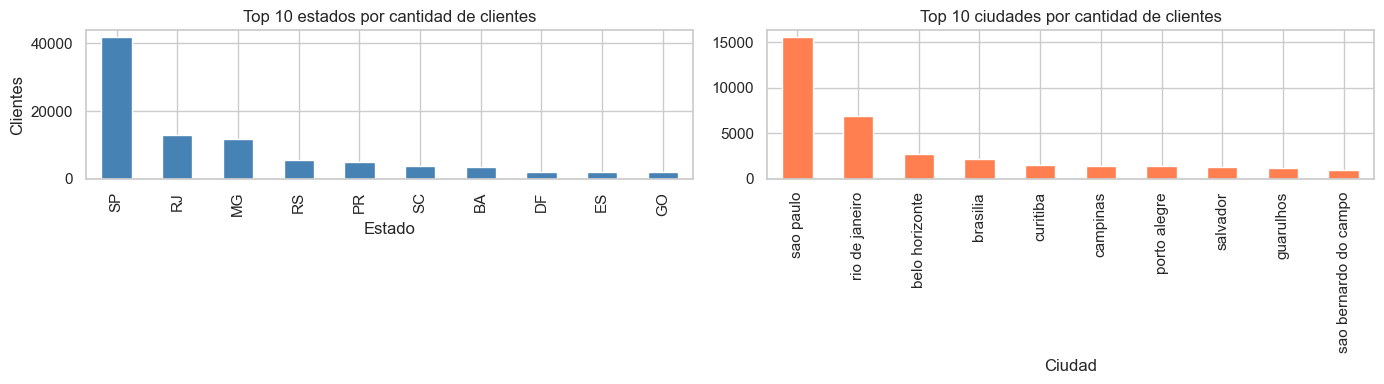


Muestra de ciudades (verificar encoding):
<ArrowStringArray>
[               'franca', 'sao bernardo do campo',             'sao paulo',
       'mogi das cruzes',              'campinas',        'jaragua do sul',
               'timoteo',              'curitiba',        'belo horizonte',
         'montes claros',        'rio de janeiro',      'lencois paulista',
         'caxias do sul',            'piracicaba',             'guarulhos',
                'pacaja',         'florianopolis',  'aparecida de goiania',
           'santo andre',               'goiania']
Length: 20, dtype: str


In [8]:
# ¿La PK es realmente única?
pk_dupes = customers.duplicated(subset='customer_id').sum()
print(f'Duplicados en customer_id (PK): {pk_dupes}')

# ¿Cuántos customer_unique_id distintos vs customer_id?
print(f'customer_id únicos:        {customers["customer_id"].nunique():,}')
print(f'customer_unique_id únicos: {customers["customer_unique_id"].nunique():,}')
print('→ Un mismo comprador puede tener múltiples customer_id (uno por pedido)')

# Top estados con más clientes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

customers['customer_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 estados por cantidad de clientes')
axes[0].set_xlabel('Estado'); axes[0].set_ylabel('Clientes')

customers['customer_city'].value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 ciudades por cantidad de clientes')
axes[1].set_xlabel('Ciudad')

plt.tight_layout()
plt.show()

# Encoding issues en nombres de ciudades
sample_cities = customers['customer_city'].dropna().unique()[:20]
print('\nMuestra de ciudades (verificar encoding):')
print(sample_cities)

---
### 3.2 `orders`

Fechas con parse fallido (NaT):
  order_purchase_timestamp                      →     0 nulos (0.00%)
  order_approved_at                             →   160 nulos (0.16%)
  order_delivered_carrier_date                  →  1783 nulos (1.79%)
  order_delivered_customer_date                 →  2965 nulos (2.98%)
  order_estimated_delivery_date                 →     0 nulos (0.00%)


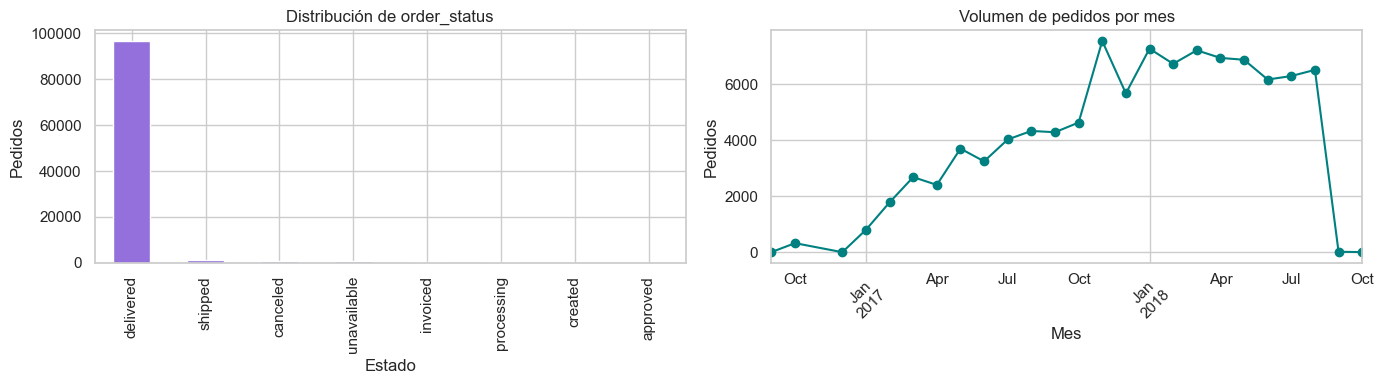


⚠ Pedidos donde aprobación < timestamp compra: 0
Pedidos entregados antes de ser enviados: 23

Rango del dataset:
  Primer pedido:  2016-09-04 21:15:19
  Último pedido:  2018-10-17 17:30:18


In [9]:
# Convertir fechas para análisis
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# ¿Cuántas fechas no pudieron parsearse?
print('Fechas con parse fallido (NaT):')
for col in date_cols:
    n = orders[col].isna().sum()
    print(f'  {col:<45} → {n:>5} nulos ({n/len(orders)*100:.2f}%)')

# Distribución de estados del pedido
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

status_counts = orders['order_status'].value_counts()
status_counts.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribución de order_status')
axes[0].set_xlabel('Estado'); axes[0].set_ylabel('Pedidos')

# Volumen de pedidos por mes
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('order_month').size().plot(ax=axes[1], color='teal', marker='o', linewidth=1.5)
axes[1].set_title('Volumen de pedidos por mes')
axes[1].set_xlabel('Mes'); axes[1].set_ylabel('Pedidos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Anomalías temporales: ¿hay pedidos donde aprobación < compra?
bad_approval = orders[orders['order_approved_at'] < orders['order_purchase_timestamp']]
print(f'\n⚠ Pedidos donde aprobación < timestamp compra: {len(bad_approval)}')

# ¿Pedidos entregados antes de ser enviados?
bad_delivery = orders[
    orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']
]
print(f'Pedidos entregados antes de ser enviados: {len(bad_delivery)}')

# ¿Rango de fechas del dataset?
print(f'\nRango del dataset:')
print(f'  Primer pedido:  {orders["order_purchase_timestamp"].min()}')
print(f'  Último pedido:  {orders["order_purchase_timestamp"].max()}')

---
### 3.3 `order_items`

Estadísticas de price y freight_value:


column,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68



Precio == 0:      0
Precio < 0:       0
Freight == 0:     383
Freight < 0:      0


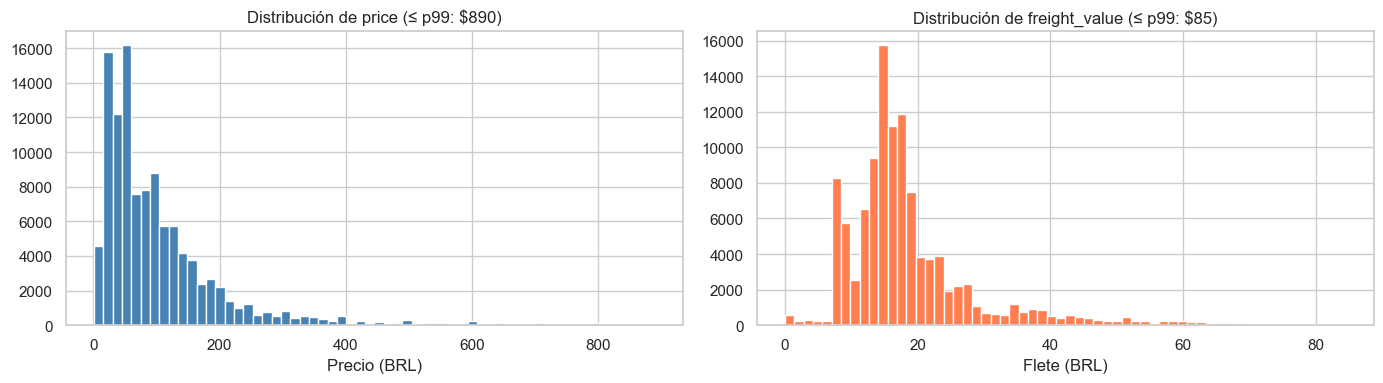


Ítems por orden — media: 1.14 | max: 21


In [10]:
# Estadísticas de precios y flete
print('Estadísticas de price y freight_value:')
display(order_items[['price', 'freight_value']].describe().round(2))

# ¿Hay precios cero o negativos?
print(f'\nPrecio == 0:      {(order_items["price"] == 0).sum()}')
print(f'Precio < 0:       {(order_items["price"] < 0).sum()}')
print(f'Freight == 0:     {(order_items["freight_value"] == 0).sum()}')
print(f'Freight < 0:      {(order_items["freight_value"] < 0).sum()}')

# Distribución de precios (excluir outliers extremos para visualización)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p99_price = order_items['price'].quantile(0.99)
order_items[order_items['price'] <= p99_price]['price'].hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución de price (≤ p99: ${p99_price:.0f})')
axes[0].set_xlabel('Precio (BRL)')

p99_freight = order_items['freight_value'].quantile(0.99)
order_items[order_items['freight_value'] <= p99_freight]['freight_value'].hist(
    bins=60, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title(f'Distribución de freight_value (≤ p99: ${p99_freight:.0f})')
axes[1].set_xlabel('Flete (BRL)')

plt.tight_layout()
plt.show()

# ¿Cuántos ítems por orden?
items_per_order = order_items.groupby('order_id')['order_item_id'].count()
print(f'\nÍtems por orden — media: {items_per_order.mean():.2f} | max: {items_per_order.max()}')

---
### 3.4 `products`

Nulos en products:


,nulls
column,
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Productos sin categoría: 610 (1.85%)

Top 15 categorías:
product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64


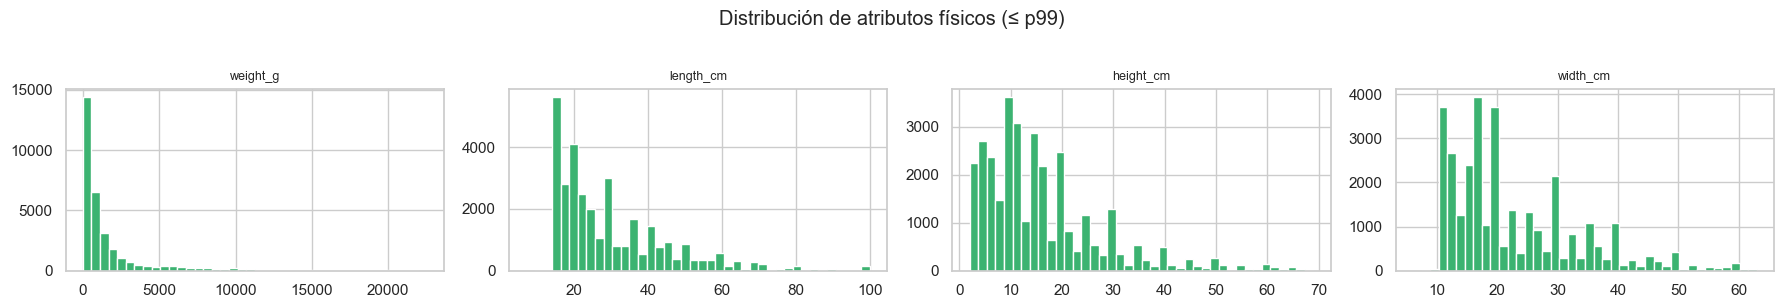

⚠  product_weight_g: 4 valores = 0


In [11]:
# Nulos por columna
print('Nulos en products:')
display(products.isnull().sum().to_frame('nulls'))

# Categorías con nulos
cat_null = products['product_category_name'].isnull().sum()
print(f'\nProductos sin categoría: {cat_null} ({cat_null/len(products)*100:.2f}%)')

# ¿Hay nombres de categoría inconsistentes?
print('\nTop 15 categorías:')
print(products['product_category_name'].value_counts().head(15))

# Distribución de dimensiones físicas
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for ax, col in zip(axes, dim_cols):
    p99 = products[col].quantile(0.99)
    products[products[col] <= p99][col].hist(bins=40, ax=ax, edgecolor='white', color='mediumseagreen')
    ax.set_title(col.replace('product_', ''), fontsize=9)
plt.suptitle('Distribución de atributos físicos (≤ p99)', y=1.02)
plt.tight_layout()
plt.show()

# ¿Hay dimensiones = 0?
for col in dim_cols:
    zeros = (products[col] == 0).sum()
    if zeros > 0:
        print(f'⚠  {col}: {zeros} valores = 0')

---
### 3.5 `payments`

Estadísticas de payment_value:


count    103886.00
mean        154.10
std         217.49
min           0.00
25%          56.79
50%         100.00
75%         171.84
max       13664.08
Name: payment_value, dtype: float64

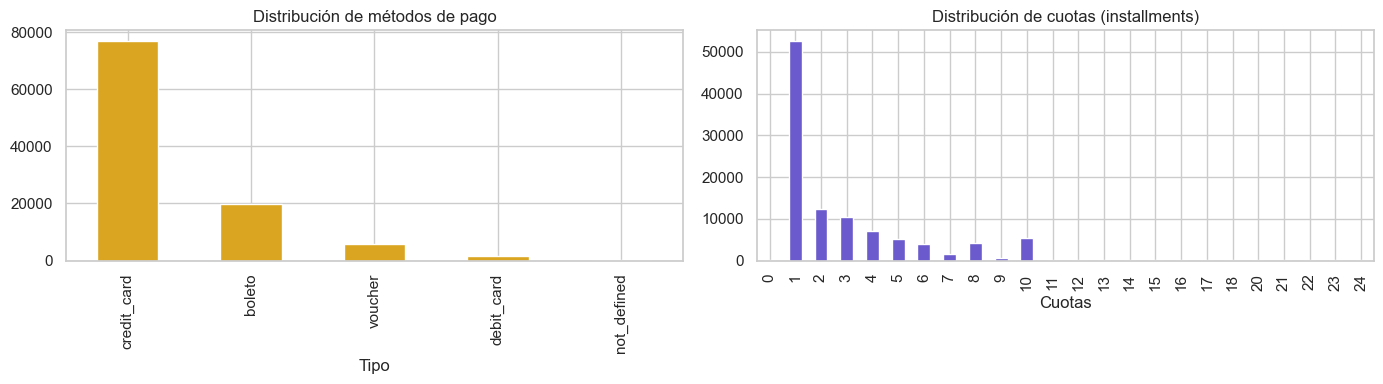

Pagos con payment_value == 0: 9
Órdenes con más de 1 registro de pago: 2,961
Máximo registros de pago por orden: 29


In [12]:
print('Estadísticas de payment_value:')
display(payments['payment_value'].describe().round(2))

# Tipos de pago
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

payments['payment_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='goldenrod', edgecolor='white')
axes[0].set_title('Distribución de métodos de pago')
axes[0].set_xlabel('Tipo')

payments['payment_installments'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='slateblue', edgecolor='white')
axes[1].set_title('Distribución de cuotas (installments)')
axes[1].set_xlabel('Cuotas')

plt.tight_layout()
plt.show()

# ¿Pagos con valor 0?
print(f'Pagos con payment_value == 0: {(payments["payment_value"] == 0).sum()}')

# ¿Una orden puede tener múltiples pagos?
multi_pay = payments.groupby('order_id').size()
print(f'Órdenes con más de 1 registro de pago: {(multi_pay > 1).sum():,}')
print(f'Máximo registros de pago por orden: {multi_pay.max()}')

---
### 3.6 `reviews`

Nulos en reviews:


,nulls
column,
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0



Reseñas duplicadas por order_id: 551


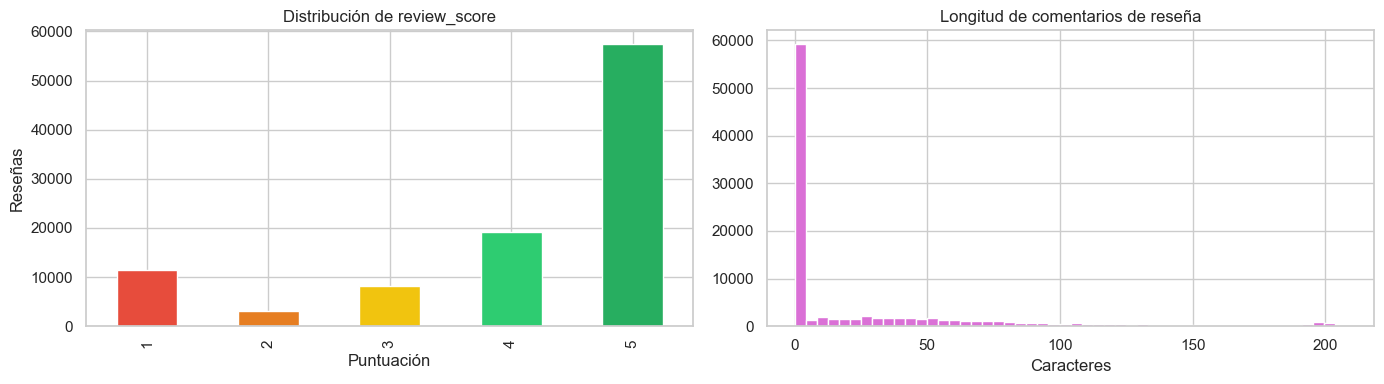

Reseñas negativas (score ≤ 2): 14,575 (14.69%)


In [13]:
# Nulos
print('Nulos en reviews:')
display(reviews.isnull().sum().to_frame('nulls'))

# Distribución de scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

score_counts = reviews['review_score'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
score_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribución de review_score')
axes[0].set_xlabel('Puntuación'); axes[0].set_ylabel('Reseñas')

# ¿Una orden tiene más de una reseña?
dupes_review = reviews.duplicated(subset='order_id').sum()
print(f'\nReseñas duplicadas por order_id: {dupes_review}')

# Longitud de comentarios
reviews['comment_len'] = reviews['review_comment_message'].fillna('').str.len()
reviews['comment_len'].hist(bins=50, ax=axes[1], color='orchid', edgecolor='white')
axes[1].set_title('Longitud de comentarios de reseña')
axes[1].set_xlabel('Caracteres')

plt.tight_layout()
plt.show()

# Reseñas negativas
neg = reviews[reviews['review_score'] <= 2]
print(f'Reseñas negativas (score ≤ 2): {len(neg):,} ({len(neg)/len(reviews)*100:.2f}%)')

---
### 3.7 `sellers`

Total vendedores: 3,095
Nulos:
column
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

seller_id únicos: 3,095  (total: 3,095)


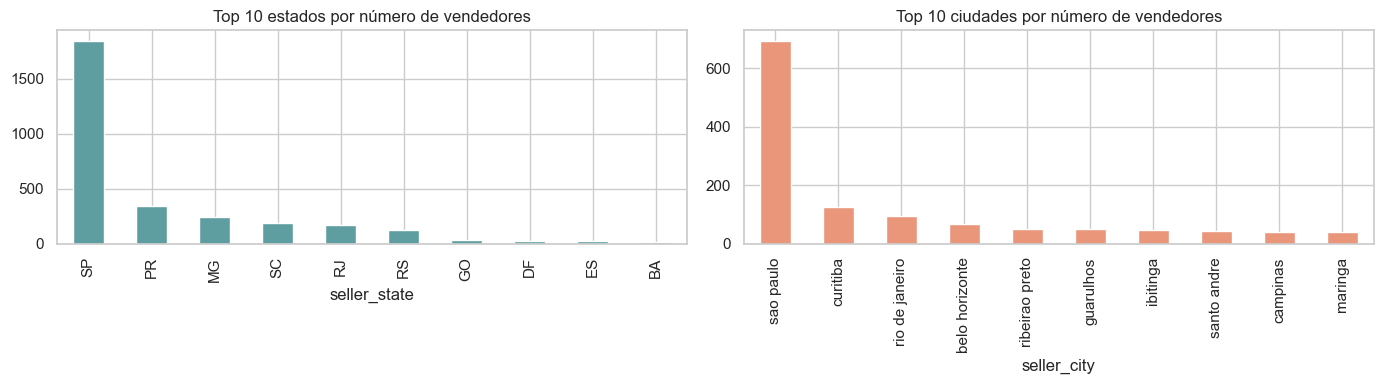


Muestra de ciudades de vendedores:
<ArrowStringArray>
[         'campinas',        'mogi guacu',    'rio de janeiro',
         'sao paulo', 'braganca paulista',            'brejao',
         'penapolis',          'curitiba',          'anapolis',
         'itirapina',           'tubarao',  'lauro de freitas',
          'imbituba',          'brasilia',      'porto seguro',
           'guaruja',         'tabatinga',             'salto',
      'tres de maio',    'belo horizonte']
Length: 20, dtype: str


In [14]:
print(f'Total vendedores: {len(sellers):,}')
print(f'Nulos:\n{sellers.isnull().sum()}')

# ¿PKs únicas?
print(f'\nseller_id únicos: {sellers["seller_id"].nunique():,}  (total: {len(sellers):,})')

# Top estados de vendedores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sellers['seller_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='cadetblue', edgecolor='white')
axes[0].set_title('Top 10 estados por número de vendedores')

sellers['seller_city'].value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='darksalmon', edgecolor='white')
axes[1].set_title('Top 10 ciudades por número de vendedores')

plt.tight_layout()
plt.show()

# Encoding issues en seller_city
sample_seller_cities = sellers['seller_city'].dropna().unique()[:20]
print('\nMuestra de ciudades de vendedores:')
print(sample_seller_cities)

---
### 3.8 `geolocation`

Total registros geolocation: 1,000,163
Nulos:
column
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

ZIP codes únicos: 19,015
Filas duplicadas por ZIP: 981,148 (98.10%)
→ Múltiples coords por ZIP es esperado pero requiere estrategia de agregación

 Latitudes fuera de Brasil:  31
 Longitudes fuera de Brasil: 26


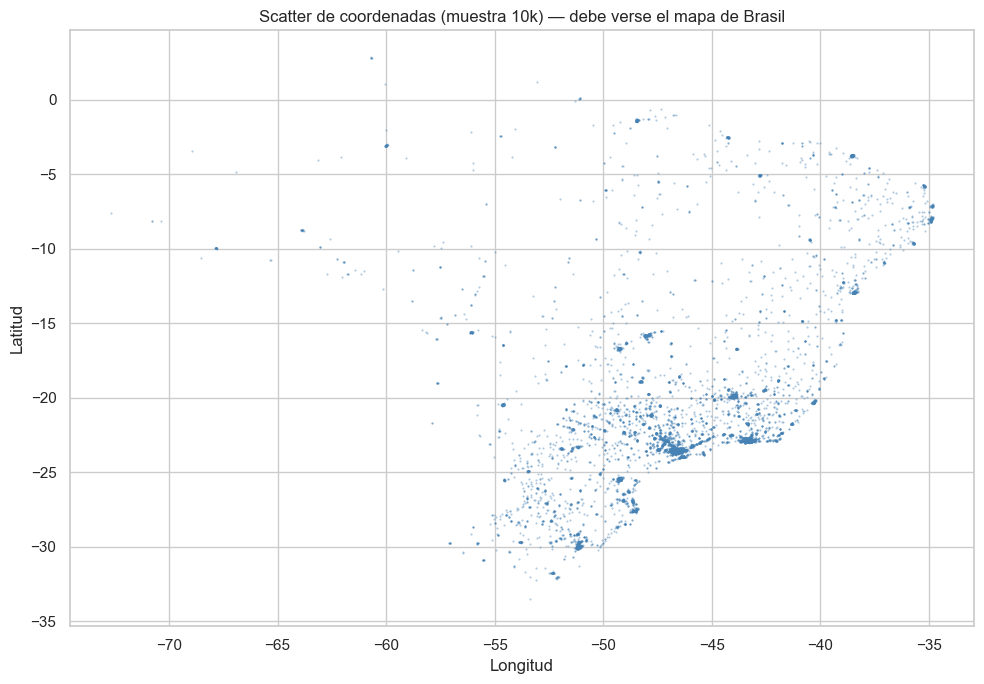

In [15]:
print(f'Total registros geolocation: {len(geolocation):,}')
print(f'Nulos:\n{geolocation.isnull().sum()}')

# Duplicados por ZIP code
dupes_zip = geolocation.duplicated(subset='geolocation_zip_code_prefix').sum()
total_zips = geolocation['geolocation_zip_code_prefix'].nunique()
print(f'\nZIP codes únicos: {total_zips:,}')
print(f'Filas duplicadas por ZIP: {dupes_zip:,} ({dupes_zip/len(geolocation)*100:.2f}%)')
print('→ Múltiples coords por ZIP es esperado pero requiere estrategia de agregación')

# ¿Hay coordenadas fuera del territorio brasileño?
# Brasil: lat ≈ [-33.7, 5.3], lng ≈ [-73.9, -28.8]
out_lat = geolocation[
    (geolocation['geolocation_lat'] < -33.7) | (geolocation['geolocation_lat'] > 5.3)
]
out_lng = geolocation[
    (geolocation['geolocation_lng'] < -73.9) | (geolocation['geolocation_lng'] > -28.8)
]
print(f'\n Latitudes fuera de Brasil:  {len(out_lat):,}')
print(f' Longitudes fuera de Brasil: {len(out_lng):,}')

# Scatter de coordenadas (muestreo para velocidad)
sample_geo = geolocation.sample(min(10000, len(geolocation)), random_state=42)
plt.figure(figsize=(10, 7))
plt.scatter(sample_geo['geolocation_lng'], sample_geo['geolocation_lat'],
            s=0.3, alpha=0.4, color='steelblue')
plt.title('Scatter de coordenadas (muestra 10k) — debe verse el mapa de Brasil')
plt.xlabel('Longitud'); plt.ylabel('Latitud')
plt.tight_layout()
plt.show()

## 4. Análisis de Integridad Referencial
Verificar que los IDs foráneos existen en sus tablas origen.

In [16]:
def check_fk(df_child, fk_col, df_parent, pk_col, child_name, parent_name):
    """Verifica integridad referencial y reporta huérfanos."""
    parent_ids = set(df_parent[pk_col])
    orphans = df_child[~df_child[fk_col].isin(parent_ids)]
    pct = len(orphans) / len(df_child) * 100
    status = 'Correcta' if len(orphans) == 0 else 'Incompleta'
    print(f'{status} {child_name}.{fk_col} → {parent_name}.{pk_col}: '
          f'{len(orphans):,} huérfanos ({pct:.2f}%)')
    return orphans

print('=== Integridad Referencial ===')
orphans = {}
orphans['orders_customers']    = check_fk(orders, 'customer_id', customers, 'customer_id', 'orders', 'customers')
orphans['items_orders']        = check_fk(order_items, 'order_id', orders, 'order_id', 'order_items', 'orders')
orphans['items_products']      = check_fk(order_items, 'product_id', products, 'product_id', 'order_items', 'products')
orphans['items_sellers']       = check_fk(order_items, 'seller_id', sellers, 'seller_id', 'order_items', 'sellers')
orphans['payments_orders']     = check_fk(payments, 'order_id', orders, 'order_id', 'payments', 'orders')
orphans['reviews_orders']      = check_fk(reviews, 'order_id', orders, 'order_id', 'reviews', 'orders')

# ¿Hay órdenes sin ítems? (debería ser 0)
orders_without_items = set(orders['order_id']) - set(order_items['order_id'])
print(f'\n Órdenes sin ítems: {len(orders_without_items):,}')

# ¿Hay órdenes sin pago?
orders_without_payment = set(orders['order_id']) - set(payments['order_id'])
print(f' Órdenes sin pago: {len(orders_without_payment):,}')

=== Integridad Referencial ===
Correcta orders.customer_id → customers.customer_id: 0 huérfanos (0.00%)
Correcta order_items.order_id → orders.order_id: 0 huérfanos (0.00%)
Correcta order_items.product_id → products.product_id: 0 huérfanos (0.00%)
Correcta order_items.seller_id → sellers.seller_id: 0 huérfanos (0.00%)
Correcta payments.order_id → orders.order_id: 0 huérfanos (0.00%)
Correcta reviews.order_id → orders.order_id: 0 huérfanos (0.00%)

 Órdenes sin ítems: 775
 Órdenes sin pago: 1


## 5. Resumen Final de Problemas Encontrados

In [17]:
issues = [
    # (tabla, columna, tipo_problema, descripción, acción_propuesta)
    ('orders',      'order_approved_at',             'Nulos',              'Pedidos sin fecha de aprobación (cancelados/pendientes)',  'Mantener nulo — es información válida'),
    ('orders',      'order_delivered_customer_date', 'Nulos',              'Pedidos no entregados aún o cancelados',                   'Mantener nulo — solo procesar delivered=True'),
    ('orders',      'fechas',                        'Anomalía temporal',  'Posibles casos donde aprobación < compra',                 'Filtrar en limpieza'),
    ('products',    'product_category_name',         'Nulos',              'Productos sin categoría asignada',                        'Imputar como "unknown" o cruzar con translation table'),
    ('products',    'dimensiones físicas',            'Nulos/Ceros',        'Filas sin datos de peso/dimensiones',                     'Imputar mediana por categoría'),
    ('geolocation', 'coordenadas',                   'Outliers espaciales','Puntos fuera del territorio de Brasil',                   'Filtrar por bounding box de Brasil'),
    ('geolocation', 'geolocation_zip_code_prefix',   'Duplicados',         'Múltiples coords por ZIP code',                           'Agregar por mediana lat/lng por ZIP'),
    ('reviews',     'review_comment_message',        'Nulos',              'Gran parte de las reseñas no tienen comentario escrito',   'Mantener nulo — es esperado'),
    ('customers',   'customer_city',                 'Encoding',           'Posibles problemas de acentos/encoding en ciudades',      'Normalizar con unidecode o similar'),
    ('sellers',     'seller_city',                   'Encoding',           'Mismo problema de encoding en ciudades de vendedores',    'Normalizar con unidecode o similar'),
    ('payments',    'payment_value',                 'Valores cero',       'Revisar registros con payment_value == 0',                'Investigar si son vouchers o errores'),
]

issues_df = pd.DataFrame(issues, columns=[
    'tabla', 'columna', 'tipo_problema', 'descripción', 'acción_propuesta'
])

display(Markdown('### Issues a resolver en Fase 2 — Limpieza'))
display(issues_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

### Issues a resolver en Fase 2 — Limpieza

tabla,columna,tipo_problema,descripción,acción_propuesta
orders,order_approved_at,Nulos,Pedidos sin fecha de aprobación (cancelados/pendientes),Mantener nulo — es información válida
orders,order_delivered_customer_date,Nulos,Pedidos no entregados aún o cancelados,Mantener nulo — solo procesar delivered=True
orders,fechas,Anomalía temporal,Posibles casos donde aprobación < compra,Filtrar en limpieza
products,product_category_name,Nulos,Productos sin categoría asignada,"Imputar como ""unknown"" o cruzar con translation table"
products,dimensiones físicas,Nulos/Ceros,Filas sin datos de peso/dimensiones,Imputar mediana por categoría
geolocation,coordenadas,Outliers espaciales,Puntos fuera del territorio de Brasil,Filtrar por bounding box de Brasil
geolocation,geolocation_zip_code_prefix,Duplicados,Múltiples coords por ZIP code,Agregar por mediana lat/lng por ZIP
reviews,review_comment_message,Nulos,Gran parte de las reseñas no tienen comentario escrito,Mantener nulo — es esperado
customers,customer_city,Encoding,Posibles problemas de acentos/encoding en ciudades,Normalizar con unidecode o similar
sellers,seller_city,Encoding,Mismo problema de encoding en ciudades de vendedores,Normalizar con unidecode o similar


---
## 6. Conclusiones

| # | Hallazgo | Severidad |
|---|----------|-----------|
| 1 | `orders` tiene columnas de fecha con nulos esperados (pedidos no entregados) | Media |
| 2 | `products` tiene ~1% de registros sin categoría | Media |
| 3 | `geolocation` tiene coordenadas fuera de Brasil y duplicados por ZIP | Alta |
| 4 | Posibles problemas de encoding en nombres de ciudades | Media |
| 5 | Integridad referencial: verificar huérfanos en joins críticos | Alta |
| 6 | `reviews` tiene un alto % sin comentario escrito — es comportamiento normal | Baja |
